# Giai đoạn 10 — Chốt mô hình

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                                 10_ChotModel                                │
└─────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 07_TachTrainTest/train.csv        —  11.407 dòng
    • 07_TachTrainTest/val.csv          —  2.444 dòng
    • 07_TachTrainTest/test_KHOA.csv    —  2.445 dòng ⚠️ MỞ LẦN ĐẦU
    • 06_NiemPhongKhaoSat/khaosat_NIEMPHONG.csv  —  676 phiếu ⚠️ MỞ LẦN ĐẦU ⭐
    • 09_TinhChinh/sieu_tham_so.json    —  cấu hình đã chốt
    • 08_MocChuan/moc_chuan.json        —  bốn mốc để so
         │
         ▼
  XỬ LÝ
    1. Kiểm CẢ HAI mã băm SHA-256 trước khi mở
    2. Huấn luyện lại trên train + val bằng cấu hình đã chốt
    3. Mở CẢ HAI tập kiểm định ĐÚNG MỘT LẦN
    4. Đo mức lạc quan: test nội bộ so với người thật  ⭐
    5. Top-1/2/3/5 hai chế độ, kèm đoán bừa và kỹ năng
    6. Hit@k · MRR · NDCG@k ở điểm vận hành: tư vấn @2 · khám phá @5
    7. Chỉ số phân loại chuẩn: F1 · precision · recall · AUC
    8. Bảng TRAIN | TEST | chênh
         │
         ▼
  ĐẦU RA
    • 10_ChotModel/metrics.json
    • 10_ChotModel/model_nganh.json     —  mô hình để backend nạp
    • 10_ChotModel/bang_ket_qua.csv
    • 10_ChotModel/chi_so_lop.csv
    • 10_ChotModel/theo_nganh.csv
    • 10_ChotModel/hinh_10_*.png        —  3 hình
```

## ⭐ Hướng 2 — hai tập kiểm định, mở cùng lúc

Đây là notebook duy nhất trong cả pipeline được phép đọc hai file niêm phong:

| Tập | n | Nguồn | Trả lời câu |
|---|--:|---|---|
| `test_KHOA.csv` | 2.445 | hồ sơ trúng tuyển | *mô hình khớp phân phối nó học đến đâu?* |
| `khaosat_NIEMPHONG.csv` | **676** | **người thật điền** | *mô hình dự đoán học sinh thật đến đâu?* ⭐ |

**Chênh lệch giữa hai con số chính là kết quả quan trọng nhất của Hướng 2.** Nó đo mức
lạc quan mà toàn bộ quy trình sinh dữ liệu bơm vào. Hướng 1 gộp hai nguồn từ Giai đoạn 6
nên không có cách nào tách ra để đo con số này.

Cả hai mã băm SHA-256 được kiểm trước khi mở. Sai một mã thì `assert` nổ ngay.

## ⚠️ Cột thứ ba — loại 5 ngành rò rỉ vòng tròn

Năm ngành (Luật, Trí tuệ nhân tạo, Quản lý Công nghiệp, Logistics, Du lịch) không có hồ
sơ trúng tuyển nào. Dòng huấn luyện của chúng sinh ra từ chính 52 phiếu khảo sát bị niêm
phong — tức dữ liệu huấn luyện đi ra từ tập kiểm định.

Vì vậy bảng kết quả có **ba cột**: test nội bộ · 676 phiếu người thật · 624 phiếu thuộc
34 ngành có hồ sơ thật. Cột cuối là con số sạch nhất.

## Phát biểu đúng về tính độc lập

> Mô hình phân loại **chưa từng thấy** phiếu nào trong 676 phiếu niêm phong.
> Bộ sinh copula ở Giai đoạn 3 **thì có**.

Không viết "hoàn toàn độc lập" — sẽ bị bắt lỗi. Lý do không tránh được đã ghi ở Giai
đoạn 6: ngành ít phiếu nhất chỉ có 6 phiếu, chia đôi thì không ước lượng nổi ma trận
hiệp phương sai 10×10.

## Huấn luyện lại trên train + val

Giai đoạn 9 đã dùng xong `val.csv` để chọn cấu hình. Từ đây nó không còn nhiệm vụ gì, nên
gộp vào train để mô hình cuối có nhiều dữ liệu nhất:

```
train 11.407 + val 2.444 = 13.851 dòng  →  mô hình cuối
test   2.445 dòng + 676 phiếu người thật →  chỉ để đo
```

## Hai tầng, đúng cách web gọi

| Tầng | Web gửi | Cách tính | Bài toán |
|---|---|---|---|
| **Khám phá** | `fieldId = null` | xếp hạng cả 39 ngành, hiện 5 | khó — mốc bừa Top-5 12,8% |
| **Tư vấn** | `fieldId = k` | xếp hạng ngành trong nhóm k, hiện 2 | dễ — mốc bừa Top-2 47,6% |

Giai đoạn 8 cho thấy chỉ 15 cột one-hot tổ hợp đã đạt mức cao ở tầng tư vấn. Nên **con
số khám phá mới là con số nói lên mô hình có học được gì không**; con số tư vấn là con số
người dùng thật sự gặp.

## Chỉ số báo cáo

Điểm vận hành: tầng tư vấn hiện **2** gợi ý, tầng khám phá hiện **5**. Báo cáo phải có đủ:

- **Top-1/2/3/5** kèm **đoán bừa** và **kỹ năng** = phần lỗi của đoán bừa mà mô hình xoá được
- **macro-F1** — mỗi ngành trọng số bằng nhau, phơi ra chuyện bỏ rơi ngành ít hồ sơ
- **weighted-F1** — chênh với macro chính là mức thiên vị ngành đông
- **AUC OvR** — chỉ ở tầng khám phá (tầng tư vấn đã che bớt ngành, hàng không tổng bằng 1)
- **TRAIN | TEST | chênh** — khoảng cách là dấu hiệu nhớ vẹt

> ⚠️ **AUC ở đây KHÁC AUC Giai đoạn 5.** Giai đoạn 5 đo *bộ phân biệt dòng sinh với dòng
> khảo sát*, và **0,50 mới là lý tưởng**. AUC ở đây đo *phân loại ngành*, càng gần 1 càng
> tốt. Trong báo cáo phải gọi đủ tên, đừng viết trống "AUC".

## ⚠️ Hạn chế phải ghi trong báo cáo

1. **Bộ sinh copula có học từ 676 phiếu niêm phong** ở Giai đoạn 3, dù mô hình phân loại
   thì không. Không tránh được — lý do ở Giai đoạn 6.
2. **5 ngành rò rỉ vòng tròn** — xem cột thứ ba của bảng kết quả.
3. **Mất cân bằng theo ngành.** Cách chữa thông thường (đánh trọng số theo ngành) bị loại
   vì thiết kế yêu cầu mọi dòng bình đẳng. Hình 10.3 đo hậu quả.
4. **Cỡ mẫu tập người thật là 676** — sai số rộng hơn tập test 2.445 dòng, nhưng đây là
   phiếu người thật tự điền.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Điểm vận hành của sản phẩm: tầng tư vấn hiện K_TU_VAN gợi ý, tầng khám phá hiện
# K_KHAM_PHA. Nhóm nhỏ nhất có 3 ngành nên Top-3 tư vấn tự đúng 100% ở nhóm đó mà
# không cần mô hình — Top-2 là mức vẫn tách được mô hình khỏi mốc đoán bừa.
# Top-1/2/3/5 vẫn báo cáo đủ để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)
K_TU_VAN = 2
K_KHAM_PHA = 5

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_HocPhanPhoi",
    4: "04_SinhDacTrung",
    5: "05_KiemDinhDuLieuSinh",
    6: "06_NiemPhongKhaoSat",
    7: "07_TachTrainTest",
    8: "08_MocChuan",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def dat_nhan(ax, xs, ys, nhan, fs=9, mau=None):
    """Đặt nhãn cạnh từng điểm mà KHÔNG đè lên nhau.

    Viết thẳng chữ lên chấm thì các điểm sát nhau (cùng 0%, cùng cỡ dữ liệu) chồng
    chữ thành một mảng không đọc được. Hàm thử lần lượt các vị trí quanh điểm, lấy
    vị trí đầu tiên không chạm nhãn đã đặt; nhãn phải dời xa có đường dẫn về điểm.
    """
    from matplotlib.text import Text

    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    vi_tri = [(5, 3), (5, -11), (-5, 3), (-5, -11)]
    for tang in range(1, 8):
        vi_tri += [(9, 3 + 11 * tang), (9, -11 - 11 * tang),
                   (-9, 3 + 11 * tang), (-9, -11 - 11 * tang)]
    da_dat = []

    def thu(x, y, t, dx, dy):
        a = ax.annotate(t, (x, y), xytext=(dx, dy), textcoords="offset points",
                        fontsize=fs, fontweight="bold", color=mau or C_DAM, zorder=6,
                        ha="left" if dx > 0 else "right", va="bottom",
                        arrowprops=(dict(arrowstyle="-", color="#8A949E", lw=.6,
                                         shrinkA=0, shrinkB=2) if abs(dy) > 12 else None))
        a.update_positions(r)
        return a, Text.get_window_extent(a, r)

    for x, y, t in zip(xs, ys, nhan):
        for dx, dy in vi_tri:
            a, hop = thu(x, y, t, dx, dy)
            if not any(hop.overlaps(h) for h in da_dat):
                break
            a.remove()
        else:
            a, hop = thu(x, y, t, *vi_tri[0])      # hết chỗ — đặt vị trí đầu
        da_dat.append(hop)


def hinh_theo_nganh(rd, cot, nhan_y, co_cham, sao=None, ghi_chu_sao=""):
    """Mỗi chấm một ngành: ngang là số dòng huấn luyện (log), dọc là độ chính xác.

    Ngành đáng chú ý (dưới 50% hoặc dưới 120 dòng) chỉ ghi SỐ cạnh chấm; tên đầy đủ
    nằm ở bảng bên phải. Không cắt cụt tên ngành, không để chữ đè lên nhau.
    """
    chu_y = (rd[(rd[cot] < .5) | (rd.n_hoc < 120)]
             .sort_values([cot, "n_hoc"]).head(22).reset_index(drop=True))
    cmap = plt.get_cmap("RdYlGn")
    fig = plt.figure(figsize=(16, 6.6))
    # wspace đủ rộng để nhãn thanh màu không chạm cột chấm màu của bảng bên phải
    gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1], wspace=0.24)
    ax, al = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    sc = ax.scatter(rd.n_hoc, rd[cot] * 100, s=14 + rd.n_test * 1.6, c=rd[cot] * 100,
                    cmap=cmap, vmin=0, vmax=100, edgecolor="white", lw=.8, zorder=3)
    ax.set_xscale("log")
    ax.set_ylim(-10, 110)
    ax.set_xlabel("Số dòng huấn luyện của ngành (thang log)")
    ax.set_ylabel(nhan_y)
    fig.colorbar(sc, ax=ax, pad=0.012, fraction=0.035).set_label(nhan_y)
    dat_nhan(ax, chu_y.n_hoc.values, chu_y[cot].values * 100,
             [str(i + 1) for i in range(len(chu_y))])

    al.axis("off")
    al.set_xlim(0, 1)
    al.set_ylim(0, 1)
    al.text(0, 1.0, "Ngành được đánh số", fontsize=12, fontweight="bold", va="bottom")
    al.text(1, 1.0, "dòng huấn luyện · độ chính xác", fontsize=9, color="#5A6672",
            ha="right", va="bottom")
    buoc = min(0.93 / max(len(chu_y), 1), 0.07)
    for i, r in chu_y.iterrows():
        y = 0.96 - i * buoc
        al.scatter([0.012], [y - buoc * 0.32], s=46, color=cmap(r[cot]),
                   edgecolor="#8A949E", lw=.5, clip_on=False)
        al.text(0.075, y, str(i + 1), fontsize=10, fontweight="bold", ha="right", va="top")
        ten = r.ten + (" *" if sao and r[sao] else "")
        al.text(0.095, y, ten, fontsize=10, va="top")
        al.text(1, y, f"{int(r.n_hoc):,}".replace(",", ".") + f" · {r[cot] * 100:.0f}%",
                fontsize=9.5, ha="right", va="top", color="#5A6672")
    chu = f"Cỡ chấm: {co_cham}."
    if sao:
        chu += f"   * {ghi_chu_sao}."
    al.text(0, 0.96 - len(chu_y) * buoc - 0.02, chu, fontsize=9, color="#5A6672", va="top")
    return fig, ax, al


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True, co_fold=False):
    """Đọc mọi thứ notebook huấn luyện cần.

    ⚠️ HƯỚNG 2 — khác Hướng 1 ở chỗ căn bản: 676 phiếu khảo sát KHÔNG bao giờ
    vào tập huấn luyện. Giai đoạn 6 niêm phong toàn bộ chúng làm tập kiểm định
    người thật độc lập; chia train/val/test chỉ diễn ra trên phần TTTH.

        Giai đoạn 3–5   d["train"] = TOÀN BỘ 676 phiếu — chỉ để BỘ SINH học
                                     phân phối, không phải để XGBoost học
        Giai đoạn 8–9   co_fold=True  → đọc train.csv và cv_folds.json của GĐ 7
        Giai đoạn 10    co_test=True  → mở CẢ HAI tập kiểm định ĐÚNG MỘT LẦN:
                                     test TTTH và 676 phiếu khảo sát niêm phong

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json — nguồn chuẩn duy nhất.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(1) / "khaosat_sach.csv"),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_fold:
        d["train"] = pd.read_csv(thu_muc(7) / "train.csv")
        d["folds"] = json.loads((thu_muc(7) / "cv_folds.json").read_text(encoding="utf-8"))
    if co_test:
        d["test"] = pd.read_csv(thu_muc(7) / "test_KHOA.csv")
        # Tập kiểm định NGƯỜI THẬT — niêm phong từ Giai đoạn 6, mở cùng lúc.
        d["khaosat_niemphong"] = pd.read_csv(thu_muc(6) / "khaosat_NIEMPHONG.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from xgboost import XGBClassifier


def mo_hinh(**kw):
    """XGBoost phân loại. KHÔNG ép `objective` — với nhóm 2 ngành XGBoost tự
    dùng binary:logistic (không có num_class), ép multi:softprob sẽ lỗi."""
    return XGBClassifier(**{**dict(
        max_depth=5, n_estimators=400, learning_rate=0.06, min_child_weight=3,
        subsample=0.8, colsample_bytree=0.6, reg_lambda=5.0,
        tree_method="hist", n_jobs=-1, verbosity=0, random_state=SEED), **kw})


class MoHinhNganh:
    """Mô hình gợi ý ngành. Chỉ dùng XGBoost phân loại — không có gì khác.

    Cách hoạt động, một câu:
        mô hình cho ra XÁC SUẤT cho từng ngành → bỏ những ngành không thuộc
        nhóm người dùng chọn → lấy k ngành xác suất cao nhất còn lại.

    Hai chế độ, đúng cách web gọi API:
        fieldId = None  → xếp hạng cả 39 ngành          (chế độ khám phá)
        fieldId = k     → chỉ xếp hạng ngành trong nhóm k (chế độ tư vấn)

    `rieng_nhom=True` → mỗi nhóm một mô hình nhỏ, chỉ học các ngành của nhóm đó.
    Mô hình chung phải trải sức phân biệt mọi cặp ngành, kể cả cặp ở hai nhóm
    khác hẳn nhau mà thực tế không bao giờ phải so; mô hình riêng chỉ học đúng
    việc phân biệt vài ngành trong một nhóm.
    """

    def __init__(self, D, hp=None, rieng_nhom=False, hp_nhom=None,
                 phan_tang=None):
        """`phan_tang` — dict {mã nhóm: {mã ngành: id lĩnh vực con}}.

        Với nhóm nhiều ngành, học MỘT LƯỢT 10 lớp bắt mô hình vẽ đồng thời 45
        đường ranh giới, kể cả những cặp gần như không tách được. Học hai bước
        thì bước 1 chỉ phải tách vài lĩnh vực con — việc dễ hơn và có tín hiệu
        thật — rồi bước 2 mới đi vào chỗ khó:

            P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)

        Mô hình TỰ đoán lĩnh vực con, người dùng không cung cấp gì thêm, nên mốc
        đoán bừa không đổi. Đo trên khối Kinh doanh (10 ngành): 44.5% → 49.3%.
        """
        self.D = D
        self.hp = hp or {}
        self.rieng_nhom = rieng_nhom
        self.hp_nhom = hp_nhom or {}
        self.phan_tang = phan_tang or {}
        self.trong = {g: [n for n in D["nganh"] if D["nhom"][n] == g]
                      for g in sorted(set(D["nhom"].values()))}

    @staticmethod
    def _fit1(X, y, hp, w=None):
        """XGBoost 3.x bắt buộc mã lớp liền mạch 0..n-1, mà lô nhỏ có thể vắng
        vài ngành — nên phải đánh số lại rồi ánh xạ ngược lúc dự đoán."""
        co = np.unique(y)
        m = mo_hinh(**hp).fit(X, np.searchsorted(co, y), sample_weight=w)
        return m, co

    def fit(self, X, y, w=None):
        X, y = np.asarray(X), np.asarray(y)
        self.m, self.co = self._fit1(X, y, self.hp, w)
        self.m_tang = {}
        if self.rieng_nhom:
            self.m_nhom = {}
            for g, ds in self.trong.items():
                sel = np.isin(y, ds)
                if len(ds) < 2 or sel.sum() < 5 or len(np.unique(y[sel])) < 2:
                    continue
                hp_g = self.hp_nhom.get(g, self.hp)
                w_g = None if w is None else w[sel]
                self.m_nhom[g] = self._fit1(X[sel], y[sel], hp_g, w_g)
                if g in self.phan_tang:
                    self.m_tang[g] = self._fit_tang(
                        X[sel], y[sel], w_g, self.phan_tang[g], hp_g)
        return self

    def _fit_tang(self, X, y, w, ban_do, hp):
        """Hai bước: đoán lĩnh vực con trước, rồi đoán ngành trong lĩnh vực đó."""
        s = np.array([ban_do[v] for v in y])
        co_s = np.unique(s)
        if len(co_s) < 2:
            return None
        m_sub = mo_hinh(**hp).fit(X, np.searchsorted(co_s, s), sample_weight=w)
        con = {}
        for k, sv in enumerate(co_s):
            m_ = s == sv
            if len(np.unique(y[m_])) < 2:
                con[k] = (None, np.unique(y[m_]))
                continue
            con[k] = self._fit1(X[m_], y[m_], hp, None if w is None else w[m_])
        return m_sub, co_s, con

    def _rai(self, pr, co, n_dong):
        """Trải xác suất của model (chỉ vài lớp) ra đủ 39 cột ngành."""
        S = np.zeros((n_dong, len(self.D["nganh"])))
        for c, ma in enumerate(co):
            S[:, self.D["i_nganh"][ma]] = pr[:, c]
        return S

    def _diem_tang(self, X, bo):
        """P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)."""
        m_sub, co_s, con = bo
        p_sub = m_sub.predict_proba(X)
        S = np.zeros((len(X), len(self.D["nganh"])))
        for k in range(len(co_s)):
            m, co = con[k]
            if m is None:
                for ma in co:
                    S[:, self.D["i_nganh"][ma]] = p_sub[:, k]
                continue
            pr = m.predict_proba(X)
            for c, ma in enumerate(co):
                S[:, self.D["i_nganh"][ma]] = p_sub[:, k] * pr[:, c]
        return S

    def diem(self, X, nhom_biet=None):
        """Xác suất trên 39 ngành. `nhom_biet` = mã nhóm người dùng chọn."""
        X = np.asarray(X)
        S = self._rai(self.m.predict_proba(X), self.co, len(X))
        if nhom_biet is None:
            return S
        nhom_biet = np.asarray(nhom_biet)
        if self.rieng_nhom:
            for g, (m, co) in self.m_nhom.items():
                sel = nhom_biet == g
                if not sel.any():
                    continue
                if self.m_tang.get(g) is not None:
                    S[sel] = self._diem_tang(X[sel], self.m_tang[g])
                else:
                    S[sel] = self._rai(m.predict_proba(X[sel]), co, int(sel.sum()))
        # Bỏ mọi ngành ngoài nhóm người dùng đã chọn
        mat_na = np.zeros_like(S)
        for i, g in enumerate(nhom_biet):
            for n in self.trong[int(g)]:
                mat_na[i, self.D["i_nganh"][n]] = 1.0
        return S * mat_na


def top_k(S, y, NG, ks=TOP_K):
    o = np.argsort(-S, axis=1)
    return {k: float(np.mean([y[i] in NG[o[i, :k]] for i in range(len(y))])) for k in ks}


def bua_toan_bo(n_lop, ks=TOP_K):
    """Đoán bừa k ngành trong toàn bộ danh mục."""
    return {k: min(k, n_lop) / n_lop for k in ks}


def bua_trong_nhom(y, nhom, ks=TOP_K):
    """Đoán bừa k ngành TRONG nhóm đúng.

    Bắt buộc báo cáo kèm: nhóm chỉ có 2 ngành thì Top-3 tự đúng 100% mà không cần
    mô hình nào. Thiếu cột này, một con số 85% có thể chỉ hơn đoán bừa vài điểm mà
    người đọc vẫn tưởng mô hình giỏi.
    """
    co = pd.Series(list(nhom.values())).value_counts()
    return {k: float(np.mean([min(k, co[nhom[m]]) / co[nhom[m]] for m in y])) for k in ks}


def ky_nang(acc, bua):
    """Phần lỗi của đoán bừa mà mô hình XOÁ ĐƯỢC.

        kỹ năng = (acc − bừa) / (1 − bừa)

    Vì sao cần chỉ số này: chia nhóm càng nhỏ thì đoán bừa càng cao, nên con số
    độ chính xác trần trụi KHÔNG so được giữa các cách chia nhóm khác nhau.
    Kỹ năng đã trừ sạch lợi thế đó — 0% là chỉ ngang đoán bừa, 100% là hoàn hảo.

    Ví dụ: 7 khối đạt 69.7% với bừa 49.2% → kỹ năng 40.3%.
           10 nhóm đạt 87.8% với bừa 75.9% → kỹ năng 49.3%.
    Con số thứ hai cao hơn thật, nhưng không cao như 87.8% so với 69.7% gợi ý.
    """
    return (acc - bua) / (1 - bua) if bua < 1 else float("nan")


def bua_pho_bien(y_hoc, y_do, nhom, ks=TOP_K):
    """Mốc đối chứng THỰC TẾ: luôn gợi ý k ngành ĐÔNG SINH VIÊN NHẤT trong nhóm.

    Đây là quy tắc mà bất kỳ ai cũng làm được bằng vài dòng code, KHÔNG cần khảo
    sát, KHÔNG cần điểm thi, KHÔNG cần mô hình. Tần suất học từ `y_hoc` (tập
    train), rồi áp lên `y_do`.

    VÌ SAO CẦN: mốc "đoán bừa" (chọn ngẫu nhiên trong nhóm) quá dễ vượt và không
    ai xây hệ thống như vậy. Phân bố ngành trong nhóm thường lệch mạnh, nên chỉ
    riêng việc gợi ý ngành phổ biến đã đúng khá nhiều. Một mô hình học máy chỉ
    thực sự có giá trị khi vượt được mốc NÀY.
    """
    y_hoc, y_do = np.asarray(y_hoc), np.asarray(y_do)
    g_hoc = np.array([nhom[m] for m in y_hoc])
    g_do = np.array([nhom[m] for m in y_do])
    out = {}
    for k in ks:
        top = {g: set(pd.Series(y_hoc[g_hoc == g]).value_counts().head(k).index)
               for g in np.unique(g_hoc)}
        out[k] = float(np.mean([y_do[i] in top.get(g_do[i], set())
                                for i in range(len(y_do))]))
    return out


def ky_nang_vs(acc, moc):
    """Phần lỗi của MỘT MỐC BẤT KỲ mà mô hình xoá được."""
    return (acc - moc) / (1 - moc) if moc < 1 else float("nan")


def chi_so_lop(S, y, NG, co_auc=True):
    """Các chỉ số phân loại chuẩn, bổ sung cho Top-k.

    Vì sao cần: độ chính xác trên 39 ngành mất cân bằng bị ngành đông chi phối.
    Mốc "luôn đoán ngành đông nhất trong nhóm" đã đạt 88,5% ở chế độ tư vấn mà
    không dùng mô hình nào. **macro-F1** cho mỗi ngành trọng số bằng nhau nên nó
    phơi ra chuyện mô hình bỏ rơi ngành ít hồ sơ; **weighted-F1** giữ trọng số
    theo cỡ ngành, luôn cao hơn — chênh lệch giữa hai con số chính là mức độ
    thiên vị ngành đông.

    ⚠️ `auc_ovr` ở đây là AUC ĐÁNH GIÁ PHÂN LOẠI (một-đối-phần-còn-lại, càng
    gần 1 càng tốt). KHÔNG phải AUC ở Giai đoạn 5 — con số đó đo bộ phân biệt
    thật/giả và **0,50 mới là lý tưởng**. Hai chỉ số trùng tên, ngược chiều
    nhau; báo cáo phải gọi rõ tên từng cái.

    Chỉ tính AUC khi `S` là phân phối xác suất đầy đủ trên 39 ngành. Ở chế độ
    tư vấn, `S` đã bị che bớt ngành ngoài nhóm nên hàng không còn tổng bằng 1 —
    truyền `co_auc=False`.
    """
    from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

    y = np.asarray(y)
    du = np.asarray(NG)[np.argmax(S, axis=1)]          # dự đoán Top-1
    ra = {
        "acc_top1": float(np.mean(du == y)),
        "f1_macro": float(f1_score(y, du, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y, du, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(y, du, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y, du, average="macro", zero_division=0)),
        "auc_ovr": float("nan"),
    }
    if co_auc:
        # roc_auc_score đòi mọi lớp trong `labels` phải xuất hiện ở y_true; ngành
        # vắng mặt trong lát cắt đang đo thì bỏ khỏi phép tính chứ không bỏ cả AUC.
        co = np.isin(np.asarray(NG), np.unique(y))
        if co.sum() >= 2:
            P = S[:, co]
            t = P.sum(axis=1, keepdims=True)
            P = np.divide(P, t, out=np.full_like(P, 1 / co.sum()), where=t > 0)
            try:
                ra["auc_ovr"] = float(roc_auc_score(
                    y, P, multi_class="ovr", average="macro",
                    labels=np.asarray(NG)[co]))
            except ValueError:
                pass
    return ra


def hang_cua_nganh_dung(S, y, NG):
    """Thứ hạng (đếm từ 1) của ngành đúng trong danh sách mô hình xếp ra."""
    o = np.argsort(-np.asarray(S), axis=1)
    NG = np.asarray(NG)
    y = np.asarray(y)
    return np.array([int(np.where(NG[o[i]] == y[i])[0][0]) + 1 for i in range(len(y))])


def chi_so_xep_hang(S, y, NG, k):
    """Chỉ số đánh giá đúng cho hệ thống trả về k gợi ý.

    Vì sao không dùng F1/precision/recall: chúng giả định hệ thống trả về MỘT
    nhãn. Hệ thống này trả 2 gợi ý ở chế độ tư vấn và 5 ở chế độ khám phá, nên
    nhóm chỉ số Top-1 đo tại một điểm vận hành không tồn tại trong sản phẩm.

    ⚠️ KHÔNG báo cáo precision@k và recall@k. Mỗi em chỉ có ĐÚNG MỘT ngành đúng,
    nên:
        recall@k    = hit@k        (trùng khít, không phải chỉ số mới)
        precision@k = hit@k / k    (chia cứng cho k, không mang thêm thông tin)
    Đưa vào bảng chỉ làm con số trông tệ đi mà không nói thêm được gì.

    Các chỉ số trả về:
        hit_k        — tỉ lệ ngành đúng nằm trong k gợi ý. Chính là Top-k.
        macro_hit_k  — trung bình hit@k TỪNG NGÀNH rồi mới lấy trung bình. Đây là
                       bản Top-k của macro-F1: mỗi ngành trọng số bằng nhau, nên
                       nó phơi ra chuyện mô hình bỏ rơi ngành ít hồ sơ, nhưng hỏi
                       tại ĐÚNG điểm vận hành thay vì hỏi ở Top-1.
        mrr          — trung bình 1/thứ hạng. Giữ được thông tin về THỨ TỰ mà
                       hit@k làm mờ đi: xếp đúng ở hạng 1 khác hẳn hạng 3.
        ndcg_k       — chấm theo vị trí, cắt ở k. Hạng 1 trọn điểm, hạng 2 được
                       1/log₂3 ≈ 0,63, ra ngoài k thì 0. Đây là chỉ số tương ứng
                       khi cần "AUC có cắt ở k" — AUC thật không có ngưỡng cắt
                       nên không tồn tại khái niệm AUC@k.
    """
    r = hang_cua_nganh_dung(S, y, NG)
    trung = r <= k
    per = pd.DataFrame({"y": np.asarray(y), "t": trung}).groupby("y").t.mean()
    return {
        "k": int(k),
        "hit_k": float(trung.mean()),
        "macro_hit_k": float(per.mean()),
        "mrr": float(np.mean(1.0 / r)),
        "ndcg_k": float(np.mean(np.where(trung, 1.0 / np.log2(r + 1), 0.0))),
        "hang_trung_vi": float(np.median(r)),
        "hang_trung_binh": float(r.mean()),
        "n_nganh_duoi_50": int((per < 0.5).sum()),
        "n_nganh": int(len(per)),
    }


def mrr_doan_bua(y, nhom=None, n_lop=None):
    """MRR của việc bốc ngẫu nhiên — mốc để so với MRR của mô hình.

    Bốc ngẫu nhiên trong m lựa chọn thì kỳ vọng 1/hạng là trung bình điều hoà
    (1/1 + 1/2 + … + 1/m) / m. Truyền `nhom` cho chế độ tư vấn (m = cỡ nhóm),
    `n_lop` cho chế độ khám phá (m = 39).
    """
    if n_lop is not None:
        return float(np.mean(1.0 / np.arange(1, n_lop + 1)))
    co = pd.Series(list(nhom.values())).value_counts()
    return float(np.mean([np.mean(1.0 / np.arange(1, co[nhom[m]] + 1)) for m in y]))


def in_chi_so_xep_hang(hang):
    """`hang` = [(tên tầng, dict từ chi_so_xep_hang, mrr đoán bừa), …]"""
    print("═" * 104)
    print(f"{'Tầng':<24}{'k':>4}{'Hit@k':>10}{'macro Hit@k':>14}{'MRR':>9}"
          f"{'MRR bừa':>10}{'NDCG@k':>10}{'hạng t.vị':>11}{'ngành <50%':>12}")
    print("─" * 104)
    for ten, d, mb in hang:
        print(f"{ten:<24}{d['k']:>4}{d['hit_k']:>9.1%}{d['macro_hit_k']:>14.1%}"
              f"{d['mrr']:>9.3f}{mb:>10.3f}{d['ndcg_k']:>10.3f}"
              f"{d['hang_trung_vi']:>11.0f}"
              f"{str(d['n_nganh_duoi_50'])+'/'+str(d['n_nganh']):>12}")
    print("═" * 104)
    print("Hit@k = Top-k · macro Hit@k = bản Top-k của macro-F1 (mỗi ngành ngang nhau)")
    print("MRR giữ thông tin THỨ TỰ mà Hit@k làm mờ · NDCG@k chấm theo vị trí, cắt ở k")
    print("KHÔNG báo cáo precision@k (= hit@k/k) và recall@k (= hit@k) — trùng lặp")


def in_chi_so_lop(hang):
    """In bảng F1 / AUC. `hang` = [(tên lát cắt, dict từ chi_so_lop, n), …]"""
    print("═" * 100)
    print(f"{'Lát cắt':<30}{'n':>8}{'Top-1':>9}{'F1 macro':>11}{'F1 w.':>9}"
          f"{'P macro':>10}{'R macro':>10}{'AUC OvR':>10}")
    print("─" * 100)
    for ten, d, n in hang:
        a = "—" if np.isnan(d["auc_ovr"]) else f"{d['auc_ovr']:.3f}"
        print(f"{ten:<30}{n:>8,}{d['acc_top1']:>9.1%}{d['f1_macro']:>11.3f}"
              f"{d['f1_weighted']:>9.3f}{d['precision_macro']:>10.3f}"
              f"{d['recall_macro']:>10.3f}{a:>10}")
    print("═" * 100)
    print("macro = mỗi ngành trọng số bằng nhau · weighted = theo cỡ ngành")
    print("chênh macro↔weighted càng lớn, mô hình càng thiên vị ngành đông")
    print("AUC OvR: càng gần 1 càng tốt — KHÁC AUC Giai đoạn 5 (0,50 là lý tưởng)")


def dong(ten, do_duoc, mocbua, ks=TOP_K):
    r = {"cau_hinh": ten}
    for k in ks:
        r[f"top{k}"], r[f"bua{k}"] = do_duoc[k], mocbua[k]
        r[f"hon{k}"] = do_duoc[k] - mocbua[k]
        r[f"kn{k}"] = ky_nang(do_duoc[k], mocbua[k])
    return r


def in_bang(rows, tieu_de="", ks=TOP_K):
    w = max([len(r["cau_hinh"]) for r in rows] + [20]) + 2
    tong = w + 35 * len(ks)
    if tieu_de:
        print("═" * tong); print(tieu_de)
    print("═" * tong)
    print(f"{'Cấu hình':{w}s}" + "".join(
        f"{'Top-'+str(k):>10s}{'bừa':>8s}{'hơn':>8s}{'kỹ năng':>9s}" for k in ks))
    print("─" * tong)
    for r in rows:
        # `hon` là hiệu hai tỉ lệ (0..1) → phải ×100 mới ra "điểm phần trăm";
        # in thẳng sẽ thành +0.4đ trong khi thực tế là +42.0đ.
        print(f"{r['cau_hinh']:{w}s}" + "".join(
            f"{r[f'top{k}']:9.1%} {r[f'bua{k}']:7.1%} {r[f'hon{k}']*100:+7.1f}đ"
            f"{r[f'kn{k}']:>9.1%}" for k in ks))
    print("═" * tong)
    print("kỹ năng = phần lỗi của đoán bừa mà mô hình xoá được — so được giữa"
          " các cách chia nhóm")


def bang_train_test(cap, ks=TOP_K):
    """Bảng TRAIN | TEST | chênh | đoán bừa | hơn bừa.

    `cap` = [(tên chế độ, chỉ số train, chỉ số test, mốc đoán bừa), …]
    Thầy yêu cầu báo cáo cả hai; khoảng cách lớn là dấu hiệu mô hình nhớ vẹt.
    """
    print("╔" + "═" * 74 + "╗")
    print("║" + " ĐỘ CHÍNH XÁC TRÊN TRAIN VÀ TEST ".center(74) + "║")
    print("╠" + "═" * 74 + "╣")
    print("║ " + f"{'':21s}{'TRAIN':>9s}{'TEST':>9s}{'chênh':>10s}"
          f"{'đoán bừa':>11s}{'hơn bừa':>11s}".ljust(73) + "║")
    for ten, tr, te, b in cap:
        print("╠" + "═" * 74 + "╣")
        print("║ " + ten.ljust(73) + "║")
        for k in ks:
            print("║ " + f"   Top-{k}{'':14s}{tr[k]:8.1%}{te[k]:9.1%}"
                  f"{(tr[k]-te[k])*100:+9.1f}đ{b[k]:10.1%}"
                  f"{(te[k]-b[k])*100:+10.1f}đ".ljust(73) + "║")
    print("╚" + "═" * 74 + "╝")

import hashlib

OUT = thu_muc(10)

D = nap(co_ttth=False)
train = pd.read_csv(thu_muc(7) / "train.csv")
val = pd.read_csv(thu_muc(7) / "val.csv")
STH = json.loads((thu_muc(9) / "sieu_tham_so.json").read_text(encoding="utf-8"))
MOC = json.loads((thu_muc(8) / "moc_chuan.json").read_text(encoding="utf-8"))
NP = json.loads((thu_muc(7) / "niem_phong.json").read_text(encoding="utf-8"))
NPK = json.loads((thu_muc(6) / "niem_phong_khaosat.json").read_text(encoding="utf-8"))

# ── KIỂM CẢ HAI NIÊM PHONG TRƯỚC KHI MỞ ──────────────────────────────────
p_test = thu_muc(7) / "test_KHOA.csv"
p_ks = thu_muc(6) / "khaosat_NIEMPHONG.csv"
for ten_, p_, mong in [("test_KHOA.csv", p_test, NP["bam_sha256"]),
                       ("khaosat_NIEMPHONG.csv", p_ks, NPK["bam_sha256"])]:
    b_ = hashlib.sha256(p_.read_bytes()).hexdigest()
    assert b_ == mong, (f"BĂM KHÔNG KHỚP — {ten_} đã bị sửa sau khi niêm phong. "
                        f"Mọi con số đo trên nó đều không dùng được.")
    print(f"✓ {ten_:<24} {b_[:32]}…")

test = pd.read_csv(p_test)          # ⚠️ MỞ LẦN ĐẦU VÀ DUY NHẤT
ksn = pd.read_csv(p_ks)             # ⚠️ MỞ LẦN ĐẦU VÀ DUY NHẤT — 676 người thật
QL = ["ma_nganh", "ma_nhom", "nguon", "rui_ro_vong_tron", "sample_weight"]
COT = [c for c in train.columns if c not in QL]

# Gộp train + val cho mô hình cuối
hoc = pd.concat([train, val], ignore_index=True)
Xh, yh, gh = hoc[COT].values, hoc.ma_nganh.values, hoc.ma_nhom.values
Xte, yte, gte = test[COT].values, test.ma_nganh.values, test.ma_nhom.values
Xks, yks, gks = ksn[COT].values, ksn.ma_nganh.values, ksn.ma_nhom.values
# 5 ngành rò rỉ vòng tròn — mặt nạ để báo cáo riêng cột 34 ngành có hồ sơ thật
m_sach = ksn.rui_ro_vong_tron.values == 0

assert set(hoc.sample_weight.unique()) == {1.0}, "trọng số phải bằng nhau"
assert not any(c in COT for c in ("nguon", "rui_ro_vong_tron")), "cột quản lý lọt vào đặc trưng"

RIENG_NHOM = bool(STH.get("rieng_nhom", False))
print(f"\nHuấn luyện       : {len(hoc):,} dòng  (train {len(train):,} + val {len(val):,})")
print(f"Test nội bộ      : {len(test):,} dòng  (từ hồ sơ trúng tuyển)")
print(f"Khảo sát n.phong : {len(ksn):,} phiếu NGƯỜI THẬT  ⭐")
print(f"   trong đó {int(m_sach.sum())} phiếu thuộc 34 ngành có hồ sơ trúng tuyển thật")
print(f"           {int((~m_sach).sum())} phiếu thuộc 5 ngành rò rỉ vòng tròn")
print(f"Trọng số   : {sorted(hoc.sample_weight.unique())}  → mọi dòng ngang nhau")
print(f"\nCấu hình chốt từ Giai đoạn 9:")
for k, v in STH["hp"].items():
    print(f"   {k:<20} {v}")
print(f"   {'rieng_nhom':<20} {RIENG_NHOM}   (tầng tư vấn)")
print(f"\nRàng buộc đã dùng để chọn: {STH['rang_buoc']['do_tren']}")
print(f"   hợp lệ {STH['n_hop_le']}/{STH['n_cau_hinh']} cấu hình")

✓ test_KHOA.csv            fca56fce42a3a9a306af4c5ecf74b5b4…
✓ khaosat_NIEMPHONG.csv    99fb31be34977fccbac79b68f0b18abf…

Huấn luyện       : 13,851 dòng  (train 11,407 + val 2,444)
Test nội bộ      : 2,445 dòng  (từ hồ sơ trúng tuyển)
Khảo sát n.phong : 676 phiếu NGƯỜI THẬT  ⭐
   trong đó 624 phiếu thuộc 34 ngành có hồ sơ trúng tuyển thật
           52 phiếu thuộc 5 ngành rò rỉ vòng tròn
Trọng số   : [1.0]  → mọi dòng ngang nhau

Cấu hình chốt từ Giai đoạn 9:
   n_estimators         150
   max_depth            3
   min_child_weight     10
   reg_lambda           5.0
   colsample_bytree     0.4
   rieng_nhom           True   (tầng tư vấn)

Ràng buộc đã dùng để chọn: khám phá (xếp hạng cả 39 ngành)
   hợp lệ 4/48 cấu hình


## 1. Huấn luyện và mở test

In [2]:
t0 = time.time()
mh = MoHinhNganh(D, hp=STH["hp"], rieng_nhom=RIENG_NHOM).fit(Xh, yh)
print(f"Huấn luyện xong {time.time()-t0:.0f}s")

S_tv, S_kp = mh.diem(Xte, gte), mh.diem(Xte)          # test nội bộ
S_tv_h, S_kp_h = mh.diem(Xh, gh), mh.diem(Xh)         # train+val
S_tv_k, S_kp_k = mh.diem(Xks, gks), mh.diem(Xks)      # ⭐ 676 phiếu NGƯỜI THẬT


def bang_topk(S, y, ten):
    return {"tap": ten, **{f"top{k}": v for k, v in top_k(S, y, D["nganh"]).items()}}


kq = pd.DataFrame([
    bang_topk(S_tv_h, yh, "TRAIN+VAL · tư vấn"),
    bang_topk(S_tv, yte, "TEST nội bộ · tư vấn"),
    bang_topk(S_tv_k, yks, "KHẢO SÁT · tư vấn"),
    bang_topk(S_tv_k[m_sach], yks[m_sach], "KHẢO SÁT 34 ngành · tư vấn"),
    bang_topk(S_kp_h, yh, "TRAIN+VAL · khám phá"),
    bang_topk(S_kp, yte, "TEST nội bộ · khám phá"),
    bang_topk(S_kp_k, yks, "KHẢO SÁT · khám phá"),
    bang_topk(S_kp_k[m_sach], yks[m_sach], "KHẢO SÁT 34 ngành · khám phá"),
])
kq.to_csv(OUT / "bang_ket_qua.csv", index=False)


def ci(p, n):
    """Khoảng tin cậy 95% cho một tỉ lệ."""
    return 1.96 * np.sqrt(max(p * (1 - p), 1e-9) / n) * 100


N_TAP = {"TRAIN+VAL": len(hoc), "TEST nội bộ": len(test),
         "KHẢO SÁT": len(ksn), "KHẢO SÁT 34 ngành": int(m_sach.sum())}
n_cua = lambda t: N_TAP[t.split(" · ")[0]]

print("\n" + "=" * 94)
print(f"{'Tập':<32}{'Top-1':>10}{'Top-2':>10}{'Top-3':>10}{'Top-5':>10}{'n':>10}")
print("-" * 94)
for r in kq.itertuples():
    if r.tap.startswith("TRAIN+VAL · khám"):
        print("-" * 94)
    print(f"{r.tap:<32}{r.top1:>9.1%}{r.top2:>10.1%}{r.top3:>10.1%}"
          f"{r.top5:>10.1%}{n_cua(r.tap):>10,}")
print("=" * 94)
print("KHẢO SÁT = 676 phiếu người thật, mô hình CHƯA TỪNG THẤY")
print("KHẢO SÁT 34 ngành = bỏ 5 ngành rò rỉ vòng tròn")

# Tư vấn đo ở điểm vận hành (K_TU_VAN gợi ý). Khám phá giữ Top-3 vì ràng buộc chống
# nhớ vẹt ở Giai đoạn 9 đặt trên đúng chỉ số đó — đo lại phải cùng thước.
g_ = lambda t, k=3: float(kq[kq.tap == t][f"top{k}"].iloc[0])
tv_h, kp_h = g_("TRAIN+VAL · tư vấn", K_TU_VAN), g_("TRAIN+VAL · khám phá")
tv_te, kp_te = g_("TEST nội bộ · tư vấn", K_TU_VAN), g_("TEST nội bộ · khám phá")
tv_ks, kp_ks = g_("KHẢO SÁT · tư vấn", K_TU_VAN), g_("KHẢO SÁT · khám phá")
tv_s, kp_s = g_("KHẢO SÁT 34 ngành · tư vấn", K_TU_VAN), g_("KHẢO SÁT 34 ngành · khám phá")

print(f"\n⭐ BA CON SỐ, BA CÂU HỎI KHÁC NHAU (tư vấn Top-{K_TU_VAN} · khám phá Top-3):")
print(f"   {'':26}{'tư vấn':>10}{'khám phá':>11}")
print(f"   {'TEST nội bộ':<26}{tv_te:>10.1%}{kp_te:>11.1%}"
      f"   ← khớp phân phối đã học?")
print(f"   {'KHẢO SÁT (676 người)':<26}{tv_ks:>10.1%}{kp_ks:>11.1%}"
      f"   ← dự đoán người thật?")
print(f"   {'KHẢO SÁT 34 ngành':<26}{tv_s:>10.1%}{kp_s:>11.1%}"
      f"   ← bỏ rò rỉ vòng tròn")
print(f"\n   Chênh TEST → KHẢO SÁT: tư vấn {(tv_te-tv_ks)*100:+.1f}đ"
      f" · khám phá {(kp_te-kp_ks)*100:+.1f}đ")
print(f"   Đó là mức lạc quan mà dữ liệu sinh bơm vào — Hướng 1 KHÔNG đo được.")
print(f"\n   Chênh 39 ngành → 34 ngành: tư vấn {(tv_ks-tv_s)*100:+.1f}đ"
      f" · khám phá {(kp_ks-kp_s)*100:+.1f}đ")
print(f"   Đó là phần do 5 ngành rò rỉ vòng tròn đóng góp.")

print(f"\nKhoảng tin cậy 95%:")
print(f"   TEST nội bộ ({len(test):,} dòng)  khám phá ±{ci(kp_te, len(test)):.1f} điểm")
print(f"   KHẢO SÁT ({len(ksn)} phiếu)     khám phá ±{ci(kp_ks, len(ksn)):.1f} điểm")

Huấn luyện xong 9s



Tập                                  Top-1     Top-2     Top-3     Top-5         n
----------------------------------------------------------------------------------------------
TRAIN+VAL · tư vấn                  81.5%     95.1%     98.8%     99.9%    13,851
TEST nội bộ · tư vấn                73.1%     91.3%     97.5%     99.8%     2,445
KHẢO SÁT · tư vấn                   58.9%     78.6%     88.5%     98.1%       676
KHẢO SÁT 34 ngành · tư vấn          56.7%     77.2%     87.5%     97.9%       624
----------------------------------------------------------------------------------------------
TRAIN+VAL · khám phá                50.7%     68.0%     77.8%     88.1%    13,851
TEST nội bộ · khám phá              42.7%     60.2%     71.4%     82.7%     2,445
KHẢO SÁT · khám phá                 30.6%     43.0%     51.3%     59.9%       676
KHẢO SÁT 34 ngành · khám phá        26.9%     40.2%     48.9%     57.7%       624
KHẢO SÁT = 676 phiếu người thật, mô hình CHƯA TỪNG THẤY
KHẢO SÁT 34 ng

In [3]:
# ═══════════ BẢNG CHÍNH — kèm mốc đoán bừa ═══════════
bua_tv = bua_trong_nhom(yte, D["nhom"])
bua_kp = bua_toan_bo(len(D["nganh"]))
bua_pb = bua_pho_bien(yh, yte, D["nhom"])
# Mốc trên tập khảo sát phải tính lại theo phân bố ngành CỦA NÓ
bua_tv_k = bua_trong_nhom(yks, D["nhom"])
bua_pb_k = bua_pho_bien(yh, yks, D["nhom"])

print("=" * 100)
print(" BẢNG CHÍNH — mọi con số kèm mốc đoán bừa")
print("=" * 100)
for ten, S, y_, bua, n_ in [
        ("TƯ VẤN · test nội bộ", S_tv, yte, bua_tv, len(test)),
        ("TƯ VẤN · 676 phiếu NGƯỜI THẬT ⭐", S_tv_k, yks, bua_tv_k, len(ksn)),
        ("KHÁM PHÁ · test nội bộ", S_kp, yte, bua_kp, len(test)),
        ("KHÁM PHÁ · 676 phiếu NGƯỜI THẬT ⭐", S_kp_k, yks, bua_kp, len(ksn))]:
    d = top_k(S, y_, D["nganh"])
    print(f"\n {ten}   (n = {n_:,})")
    print(f"   {'':8}{'mô hình':>10}{'đoán bừa':>11}{'hơn bừa':>10}{'kỹ năng':>10}")
    for k in TOP_K:
        print(f"   Top-{k:<4}{d[k]:>10.1%}{bua[k]:>11.1%}"
              f"{(d[k]-bua[k])*100:>+9.1f}đ{ky_nang(d[k], bua[k]):>10.1%}")
print("\n" + "=" * 100)
print("kỹ năng = (mô hình − bừa) / (1 − bừa)  — so sánh được giữa các cách chia nhóm")

# Mốc khó nhất: luôn gợi ý ngành ĐÔNG NHẤT trong nhóm. Không cần khảo sát, không
# cần điểm, không cần mô hình — vài dòng code là ra. Vượt được mốc NÀY mới có nghĩa.
print(f"\n── MỐC KHÓ NHẤT: luôn gợi ý ngành đông nhất trong nhóm ──")
print(f"   đo trên 676 phiếu NGƯỜI THẬT")
print(f"   {'':8}{'mô hình':>10}{'mốc này':>11}{'hơn':>10}{'kỹ năng':>10}")
d_tv = top_k(S_tv_k, yks, D["nganh"])
for k in TOP_K:
    print(f"   Top-{k:<4}{d_tv[k]:>10.1%}{bua_pb_k[k]:>11.1%}"
          f"{(d_tv[k]-bua_pb_k[k])*100:>+9.1f}đ{ky_nang_vs(d_tv[k], bua_pb_k[k]):>10.1%}")
if d_tv[K_TU_VAN] <= bua_pb_k[K_TU_VAN]:
    print(f"\n   ⚠️  Mô hình KHÔNG vượt được mốc này ở Top-{K_TU_VAN} trên người thật.")
    print(f"       Phải nêu thẳng — đây là kết quả quan trọng nhất của Hướng 2.")

 BẢNG CHÍNH — mọi con số kèm mốc đoán bừa

 TƯ VẤN · test nội bộ   (n = 2,445)
              mô hình   đoán bừa   hơn bừa   kỹ năng
   Top-1        73.1%      23.8%    +49.3đ     64.7%
   Top-2        91.3%      47.7%    +43.7đ     83.4%
   Top-3        97.5%      71.5%    +26.1đ     91.4%
   Top-5        99.8%      94.4%     +5.3đ     95.6%

 TƯ VẤN · 676 phiếu NGƯỜI THẬT ⭐   (n = 676)
              mô hình   đoán bừa   hơn bừa   kỹ năng
   Top-1        58.9%      23.4%    +35.5đ     46.3%
   Top-2        78.6%      46.7%    +31.8đ     59.7%
   Top-3        88.5%      70.1%    +18.4đ     61.4%
   Top-5        98.1%      93.2%     +4.9đ     71.8%

 KHÁM PHÁ · test nội bộ   (n = 2,445)
              mô hình   đoán bừa   hơn bừa   kỹ năng
   Top-1        42.7%       2.6%    +40.2đ     41.2%
   Top-2        60.2%       5.1%    +55.0đ     58.0%
   Top-3        71.4%       7.7%    +63.7đ     69.0%
   Top-5        82.7%      12.8%    +69.9đ     80.2%

 KHÁM PHÁ · 676 phiếu NGƯỜI THẬT ⭐   (n 

## 2. Chỉ số ở ĐÚNG điểm vận hành — Hit@k, MRR, NDCG@k ⭐

Sản phẩm hiện **2 gợi ý** ở tầng tư vấn và **5 gợi ý** ở tầng khám phá. Đây là bảng
đo tại đúng hai điểm đó — bảng chỉ tiêu chính của khoá luận.

| Chỉ số | Trả lời câu |
|---|---|
| **Hit@k** | *"ngành đúng có nằm trong k gợi ý không?"* — chính là Top-k |
| **macro Hit@k** | như trên nhưng **mỗi ngành trọng số bằng nhau** → bản Top-k của macro-F1 |
| **MRR** | *"ngành đúng nằm ở hạng mấy?"* — giữ thông tin thứ tự mà Hit@k làm mờ |
| **NDCG@k** | chấm theo vị trí rồi cắt ở k: hạng 1 trọn điểm, hạng 2 được ≈0,63 |
| **Hạng trung vị** | câu dễ hiểu nhất: *"quá nửa số em, ngành đúng nằm ở hạng mấy?"* |

### ⚠️ Vì sao KHÔNG có precision@k và recall@k

Mỗi em chỉ có **đúng một** ngành đúng. Khi đó hai chỉ số kia suy biến:

```
recall@k     = hit@k           →  trùng khít cột Top-k, không phải chỉ số mới
precision@k  = hit@k / k       →  tư vấn chia cứng cho 2, khám phá chia cứng cho 5
```

`precision@k` chỉ phản ánh việc giao diện hiện 2 hay 5 thẻ, không nói gì về mô hình.
Đưa vào bảng làm con số trông tệ đi mà không thêm thông tin, và người chấm sẽ hỏi ngay
*"sao recall@3 trùng khít cột Top-3?"*.

### ⚠️ Vì sao KHÔNG có "AUC@2" hay "AUC@5"

AUC theo định nghĩa **không có ngưỡng cắt** — nó xét toàn bộ thứ hạng, nên không tồn
tại khái niệm AUC@k. Chỉ số đóng đúng vai trò đó khi cần cắt ở k là **NDCG@k**.


In [4]:
xh, luu_xh = [], []
for ten_, S_, y_, k_, mb in [
        ("TƯ VẤN · test", S_tv, yte, K_TU_VAN, mrr_doan_bua(yte, nhom=D["nhom"])),
        ("TƯ VẤN · NGƯỜI THẬT ⭐", S_tv_k, yks, K_TU_VAN, mrr_doan_bua(yks, nhom=D["nhom"])),
        ("KHÁM PHÁ · test", S_kp, yte, K_KHAM_PHA, mrr_doan_bua(yte, n_lop=len(D["nganh"]))),
        ("KHÁM PHÁ · NGƯỜI THẬT ⭐", S_kp_k, yks, K_KHAM_PHA,
         mrr_doan_bua(yks, n_lop=len(D["nganh"])))]:
    d_ = chi_so_xep_hang(S_, y_, D["nganh"], k_)
    xh.append((ten_, d_, mb))
    luu_xh.append({"tang": ten_, **d_, "mrr_doan_bua": mb})

in_chi_so_xep_hang(xh)
pd.DataFrame(luu_xh).to_csv(OUT / "chi_so_xep_hang.csv", index=False)

dtv, dkp = xh[1][1], xh[3][1]      # cột NGƯỜI THẬT là cột của kết luận
dtvt, dkpt = xh[0][1], xh[2][1]    # cột test nội bộ để đối chiếu
print(f"\n── ĐỌC BẢNG ──")
print(f"Trên 676 phiếu NGƯỜI THẬT:")
print(f"   hạng trung vị tầng tư vấn   = {dtv['hang_trung_vi']:.0f}")
print(f"   hạng trung vị tầng khám phá = {dkp['hang_trung_vi']:.0f} trên 39 ngành")
print(f"\nSo với test nội bộ (hạng trung vị {dtvt['hang_trung_vi']:.0f}"
      f" và {dkpt['hang_trung_vi']:.0f}):")
print(f"   MRR tư vấn   {dtvt['mrr']:.3f} → {dtv['mrr']:.3f}"
      f"   ({dtv['mrr']-dtvt['mrr']:+.3f})")
print(f"   MRR khám phá {dkpt['mrr']:.3f} → {dkp['mrr']:.3f}"
      f"   ({dkp['mrr']-dkpt['mrr']:+.3f})")

print(f"\nmacro Hit@k so với Hit@k — khoảng cách là mức bỏ rơi ngành nhỏ:")
print(f"   tư vấn @{K_TU_VAN}   {dtv['hit_k']:.1%} → macro {dtv['macro_hit_k']:.1%}"
      f"   (−{(dtv['hit_k']-dtv['macro_hit_k'])*100:.1f} điểm,"
      f" {dtv['n_nganh_duoi_50']}/{dtv['n_nganh']} ngành dưới 50%)")
print(f"   khám phá @{K_KHAM_PHA} {dkp['hit_k']:.1%} → macro {dkp['macro_hit_k']:.1%}"
      f"   (−{(dkp['hit_k']-dkp['macro_hit_k'])*100:.1f} điểm,"
      f" {dkp['n_nganh_duoi_50']}/{dkp['n_nganh']} ngành dưới 50%)")
print(f"\n   Đây là con số phải đưa kèm, không được đưa mình Hit@k.")

print(f"\nMRR so với đoán bừa (người thật):")
print(f"   tư vấn   {dtv['mrr']:.3f}  vs bừa {xh[1][2]:.3f}"
      f"   ({dtv['mrr']-xh[1][2]:+.3f})")
print(f"   khám phá {dkp['mrr']:.3f}  vs bừa {xh[3][2]:.3f}"
      f"   ({dkp['mrr']-xh[3][2]:+.3f})")

════════════════════════════════════════════════════════════════════════════════════════════════════════
Tầng                       k     Hit@k   macro Hit@k      MRR   MRR bừa    NDCG@k  hạng t.vị  ngành <50%
────────────────────────────────────────────────────────────────────────────────────────────────────────
TƯ VẤN · test              2    91.3%         82.6%    0.849     0.501     0.846          1        4/39
TƯ VẤN · NGƯỜI THẬT ⭐      2    78.6%         76.0%    0.746     0.495     0.713          1        6/39
KHÁM PHÁ · test            5    82.7%         70.9%    0.598     0.109     0.640          2        7/39
KHÁM PHÁ · NGƯỜI THẬT ⭐    5    59.9%         57.4%    0.451     0.109     0.461          3       13/39
════════════════════════════════════════════════════════════════════════════════════════════════════════
Hit@k = Top-k · macro Hit@k = bản Top-k của macro-F1 (mỗi ngành ngang nhau)
MRR giữ thông tin THỨ TỰ mà Hit@k làm mờ · NDCG@k chấm theo vị trí, cắt ở k
KHÔNG báo cá

## 3. Chỉ số phân loại Top-1 — để đối chiếu

Nhóm chỉ số này giả định hệ thống trả về **một** nhãn duy nhất. Sản phẩm trả 2 gợi ý ở
tầng tư vấn và 5 ở tầng khám phá, nên chúng đo tại một điểm vận hành **không tồn tại**
trong sản phẩm — vì vậy chúng thấp hơn hẳn bảng mục 2.

Vẫn báo cáo, để đối chiếu được với các nghiên cứu phân loại đơn nhãn. Nhưng chỉ tiêu
đánh giá chính là Hit@k và MRR ở mục 2.


In [5]:
hang, luu_cs, CS = [], [], {}
for nhan, S_, y_, n_, auc_ in [
        ("tư vấn · TRAIN+VAL", S_tv_h, yh, len(yh), False),
        ("tư vấn · TEST", S_tv, yte, len(yte), False),
        ("tư vấn · NGƯỜI THẬT", S_tv_k, yks, len(yks), False),
        ("khám phá · TRAIN+VAL", S_kp_h, yh, len(yh), True),
        ("khám phá · TEST", S_kp, yte, len(yte), True),
        ("khám phá · NGƯỜI THẬT", S_kp_k, yks, len(yks), True)]:
    d_ = chi_so_lop(S_, y_, D["nganh"], co_auc=auc_)
    hang.append((nhan, d_, n_))
    CS[nhan] = d_
    luu_cs.append({"lat_cat": nhan, "n": n_, **d_})

in_chi_so_lop(hang)
pd.DataFrame(luu_cs).to_csv(OUT / "chi_so_lop.csv", index=False)

cs = CS["khám phá · NGƯỜI THẬT"]      # cột của kết luận
cs_h = CS["khám phá · TRAIN+VAL"]
cs_te = CS["khám phá · TEST"]
cs_tv = CS["tư vấn · NGƯỜI THẬT"]

print(f"\n── ĐỌC BẢNG ──")
print(f"macro-F1 {cs['f1_macro']:.3f}  vs  weighted-F1 {cs['f1_weighted']:.3f}"
      f"   → chênh {cs['f1_weighted']-cs['f1_macro']:+.3f}")
if cs["f1_weighted"] - cs["f1_macro"] > 0.05:
    print(f"   Chênh đáng kể — mô hình làm tốt ở ngành đông, kém ở ngành ít hồ sơ.")
    print(f"   Hình 10.3 chỉ rõ ngành nào.")
else:
    print(f"   Chênh nhỏ — mô hình đối xử khá đều giữa ngành đông và ngành ít hồ sơ.")

print(f"\nprecision macro {cs['precision_macro']:.3f} · recall macro {cs['recall_macro']:.3f}")
if cs["precision_macro"] > cs["recall_macro"] + 0.05:
    print(f"   precision > recall: gợi ý ra thì khá đúng, nhưng BỎ SÓT nhiều ngành.")
elif cs["recall_macro"] > cs["precision_macro"] + 0.05:
    print(f"   recall > precision: quét rộng, bắt được nhiều nhưng gợi ý sai cũng nhiều.")

print(f"\nAUC OvR khám phá: train+val {cs_h['auc_ovr']:.3f}"
      f" → test {cs_te['auc_ovr']:.3f} → NGƯỜI THẬT {cs['auc_ovr']:.3f}")
print(f"   Càng gần 1 càng tốt. KHÁC AUC Giai đoạn 5, nơi 0,50 mới là lý tưởng.")
print(f"\nTop-1 khám phá {cs['acc_top1']:.1%} · Top-1 tư vấn {cs_tv['acc_top1']:.1%}")
print(f"   Top-3 khám phá {kp_te:.1%} — hơn Top-1 {(kp_te-cs['acc_top1'])*100:.1f} điểm.")
print(f"   Ép hệ thống về 1 gợi ý thì mất chừng đó.")

════════════════════════════════════════════════════════════════════════════════════════════════════
Lát cắt                              n    Top-1   F1 macro    F1 w.   P macro   R macro   AUC OvR
────────────────────────────────────────────────────────────────────────────────────────────────────
tư vấn · TRAIN+VAL              13,851    81.5%      0.760    0.809     0.830     0.737         —
tư vấn · TEST                    2,445    73.1%      0.637    0.721     0.695     0.624         —
tư vấn · NGƯỜI THẬT                676    58.9%      0.529    0.566     0.602     0.559         —
khám phá · TRAIN+VAL            13,851    50.7%      0.480    0.496     0.584     0.452     0.959
khám phá · TEST                  2,445    42.7%      0.370    0.414     0.429     0.349     0.935
khám phá · NGƯỜI THẬT              676    30.6%      0.270    0.277     0.299     0.303     0.872
════════════════════════════════════════════════════════════════════════════════════════════════════
macro = mỗi

In [6]:
# ═══════════ BẢNG TRAIN | TEST | chênh ═══════════
bang_train_test([
    ("TƯ VẤN — cột TEST là 676 phiếu NGƯỜI THẬT", top_k(S_tv_h, yh, D["nganh"]),
     top_k(S_tv_k, yks, D["nganh"]), bua_tv_k),
    ("KHÁM PHÁ — cột TEST là 676 phiếu NGƯỜI THẬT", top_k(S_kp_h, yh, D["nganh"]),
     top_k(S_kp_k, yks, D["nganh"]), bua_kp),
])

gap_kp = kp_h - kp_te
gap_kp_ks = kp_h - kp_ks
rb = STH["rang_buoc"]
print(f"\nRàng buộc Giai đoạn 9 (đo trên val)  : khám phá chênh ≤ {rb['kp_gap_toi_da']:.0%}")
print(f"Thực tế trên test nội bộ            : {gap_kp*100:+.1f} điểm")
print(f"Thực tế trên 676 phiếu NGƯỜI THẬT   : {gap_kp_ks*100:+.1f} điểm  ⭐")
if gap_kp <= rb["kp_gap_toi_da"]:
    print(f"\n   ✓ Ràng buộc giữ được trên test nội bộ.")
else:
    print(f"\n   ⚠️ Vượt ngưỡng ngay ở test nội bộ.")
print(f"   Khoảng cách tới người thật ({gap_kp_ks*100:.1f} điểm) là con số PHẢI nêu:")
print(f"   nó đo mức lạc quan của toàn bộ quy trình sinh dữ liệu, không chỉ của mô hình.")
print(f"   Hướng 1 không có cách nào đo được con số này.")

╔══════════════════════════════════════════════════════════════════════════╗
║                     ĐỘ CHÍNH XÁC TRÊN TRAIN VÀ TEST                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║                          TRAIN     TEST     chênh   đoán bừa    hơn bừa  ║
╠══════════════════════════════════════════════════════════════════════════╣
║ TƯ VẤN — cột TEST là 676 phiếu NGƯỜI THẬT                                ║
║    Top-1                 81.5%    58.9%    +22.6đ     23.4%     +35.5đ   ║
║    Top-2                 95.1%    78.6%    +16.5đ     46.7%     +31.8đ   ║
║    Top-3                 98.8%    88.5%    +10.3đ     70.1%     +18.4đ   ║
║    Top-5                 99.9%    98.1%     +1.9đ     93.2%      +4.9đ   ║
╠══════════════════════════════════════════════════════════════════════════╣
║ KHÁM PHÁ — cột TEST là 676 phiếu NGƯỜI THẬT                              ║
║    Top-1                 50.7%    30.6%    +20.1đ      2.6%     +28.1đ   ║

   💾 hinh_10_1_ket_qua.png


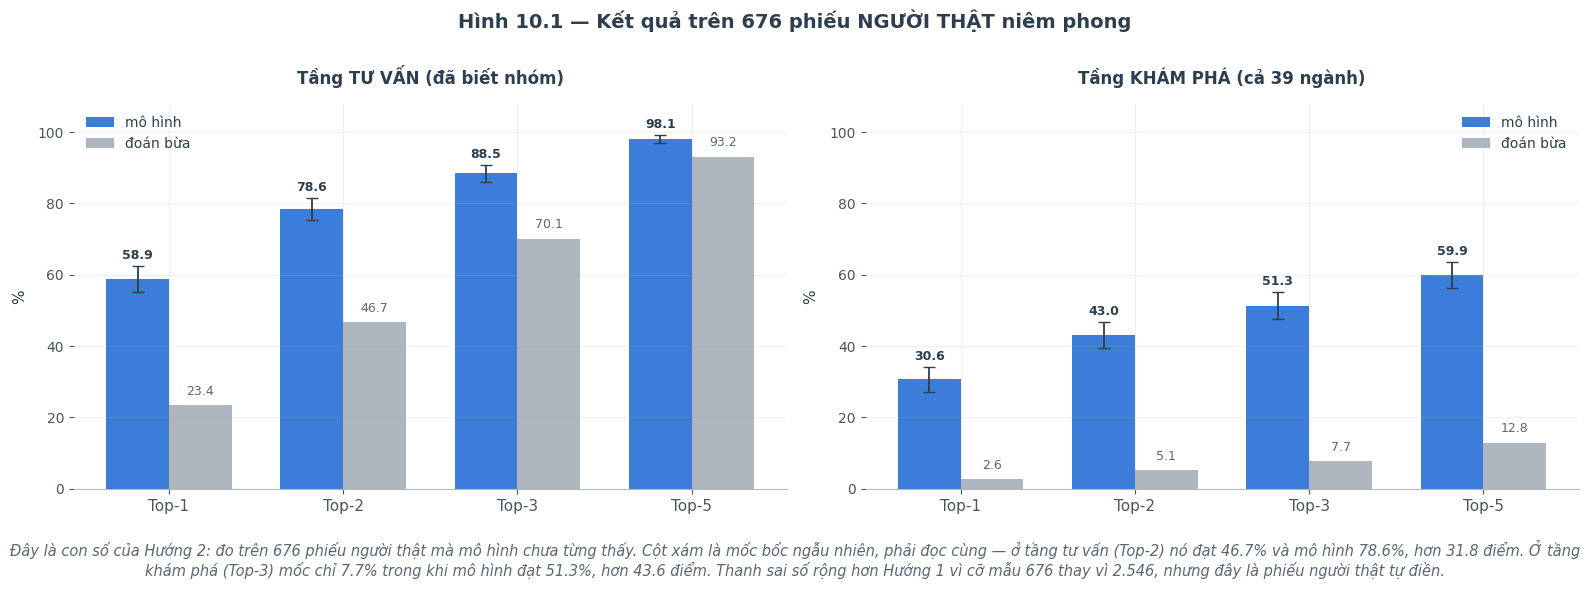

In [7]:
# ═══════════ HÌNH 10.1 — Kết quả chính ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 5.2))
for ax, (ten_, S, bua) in zip([a1, a2], [
        ("Tầng TƯ VẤN (đã biết nhóm)", S_tv_k, bua_tv_k),
        ("Tầng KHÁM PHÁ (cả 39 ngành)", S_kp_k, bua_kp)]):
    d = top_k(S, yks, D["nganh"])
    x = np.arange(len(TOP_K)); w_ = .36
    mh_v = [d[k] * 100 for k in TOP_K]
    bu_v = [bua[k] * 100 for k in TOP_K]
    er = [ci(d[k], len(ksn)) for k in TOP_K]
    ax.bar(x - w_/2, mh_v, w_, color=C_XANH, label="mô hình", yerr=er,
           error_kw=dict(ecolor=C_DAM, lw=1.3, capsize=4))
    ax.bar(x + w_/2, bu_v, w_, color=C_XAM, label="đoán bừa")
    ax.set_xticks(x); ax.set_xticklabels([f"Top-{k}" for k in TOP_K], fontsize=11)
    ax.set_ylabel("%"); ax.set_ylim(0, 108); ax.legend(fontsize=10)
    ax.set_title(ten_, fontsize=12)
    for i, (m_, b_) in enumerate(zip(mh_v, bu_v)):
        ax.text(i - w_/2, m_ + er[i] + 2, f"{m_:.1f}", ha="center", fontsize=9,
                fontweight="bold")
        ax.text(i + w_/2, b_ + 3, f"{b_:.1f}", ha="center", fontsize=9, color="#5A6672")

fig.suptitle(f"Hình 10.1 — Kết quả trên {len(ksn)} phiếu NGƯỜI THẬT niêm phong",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_10_1_ket_qua.png",
    f"Đây là con số của Hướng 2: đo trên {len(ksn)} phiếu người thật mà mô hình chưa "
    f"từng thấy. Cột xám là mốc bốc ngẫu nhiên, phải đọc cùng — ở tầng tư vấn "
    f"(Top-{K_TU_VAN}) nó đạt {bua_tv_k[K_TU_VAN]:.1%} và mô hình {tv_ks:.1%}, hơn "
    f"{(tv_ks-bua_tv_k[K_TU_VAN])*100:.1f} điểm. Ở tầng khám phá (Top-3) mốc chỉ "
    f"{bua_kp[3]:.1%} trong khi mô hình đạt {kp_ks:.1%}, "
    f"hơn {(kp_ks-bua_kp[3])*100:.1f} điểm. Thanh sai số rộng hơn Hướng 1 vì cỡ mẫu "
    f"{len(ksn)} thay vì 2.546, nhưng đây là phiếu người thật tự điền.")
plt.show()

   💾 hinh_10_2_ba_cach_do.png


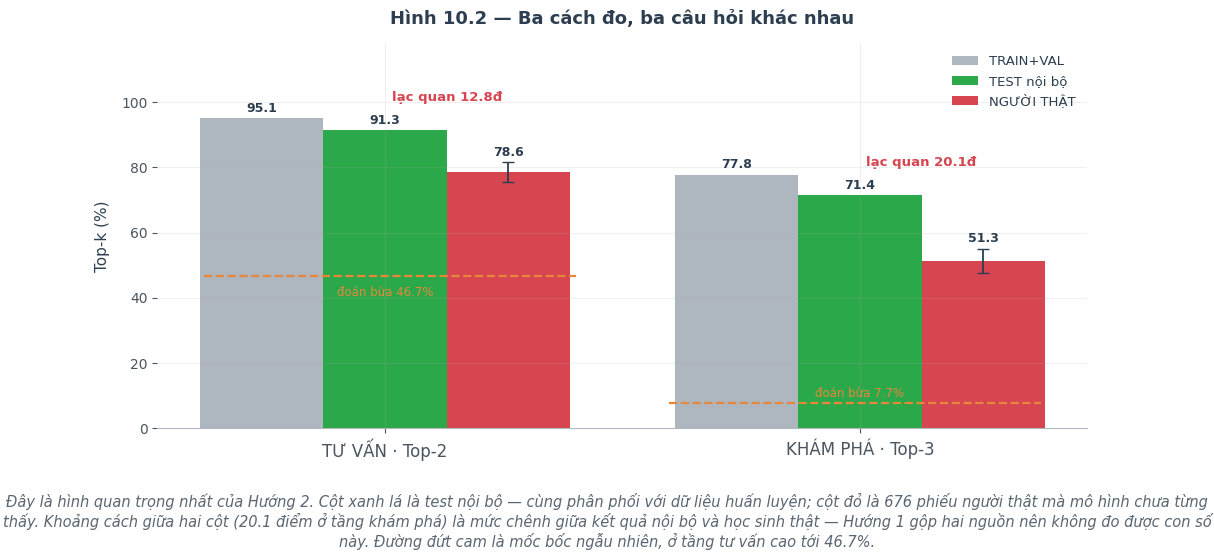

In [8]:
# ═══════════ HÌNH 10.2 — TRAIN+VAL so với TEST ═══════════
fig, ax = plt.subplots(figsize=(12, 5))
nhom_ = [f"TƯ VẤN · Top-{K_TU_VAN}", "KHÁM PHÁ · Top-3"]
# Không dùng emoji trong chữ của hình: DejaVu Sans không có glyph, ra ô vuông.
bo3 = [("TRAIN+VAL", [tv_h*100, kp_h*100], C_XAM),
       ("TEST nội bộ", [tv_te*100, kp_te*100], C_GA),
       ("NGƯỜI THẬT", [tv_ks*100, kp_ks*100], C_THAT)]
x = np.arange(2); w_ = .26
for j, (ten_, v_, mau_) in enumerate(bo3):
    er = [ci(tv_ks, len(ksn)), ci(kp_ks, len(ksn))] if j == 2 else None
    ax.bar(x + (j-1)*w_, v_, w_, color=mau_, label=ten_, yerr=er,
           error_kw=dict(ecolor=C_DAM, lw=1.3, capsize=4))
    for i, a_ in enumerate(v_):
        # số đặt trên đầu thanh sai số, không để thanh sai số gạch qua chữ
        ax.text(i + (j-1)*w_, a_ + (er[i] if er else 0) + 2, f"{a_:.1f}",
                ha="center", fontsize=9, fontweight="bold")
for i, (a_, b_) in enumerate(zip(bo3[1][1], bo3[2][1])):
    ax.text(i + w_/2, max(a_, b_) + 9, f"lạc quan {a_-b_:.1f}đ", ha="center",
            fontsize=9.5, color=C_THAT, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(nhom_, fontsize=12)
ax.set_ylabel("Top-k (%)"); ax.legend(fontsize=9.5); ax.set_ylim(0, 118)
ax.axhline(bua_tv_k[K_TU_VAN] * 100, xmin=.05, xmax=.45, color=C_CAM, ls="--", lw=1.6)
ax.axhline(bua_kp[3] * 100, xmin=.55, xmax=.95, color=C_CAM, ls="--", lw=1.6)
ax.text(0, bua_tv_k[K_TU_VAN] * 100 - 6, f"đoán bừa {bua_tv_k[K_TU_VAN]:.1%}", ha="center",
        fontsize=8.5, color=C_CAM)
ax.text(1, bua_kp[3] * 100 + 2, f"đoán bừa {bua_kp[3]:.1%}", ha="center",
        fontsize=8.5, color=C_CAM)
ax.set_title("Hình 10.2 — Ba cách đo, ba câu hỏi khác nhau")
luu(fig, OUT, "hinh_10_2_ba_cach_do.png",
    f"Đây là hình quan trọng nhất của Hướng 2. Cột xanh lá là test nội bộ — cùng phân "
    f"phối với dữ liệu huấn luyện; cột đỏ là {len(ksn)} phiếu người thật mà mô hình chưa "
    f"từng thấy. Khoảng cách giữa hai cột ({(kp_te-kp_ks)*100:.1f} điểm ở tầng khám phá) "
    f"là mức chênh giữa kết quả nội bộ và học sinh thật — Hướng 1 gộp hai nguồn nên không "
    f"đo được con số này. Đường đứt cam là mốc bốc ngẫu "
    f"nhiên, ở tầng tư vấn cao tới {bua_tv_k[K_TU_VAN]:.1%}.")
plt.show()

   💾 hinh_10_3_theo_nganh.png


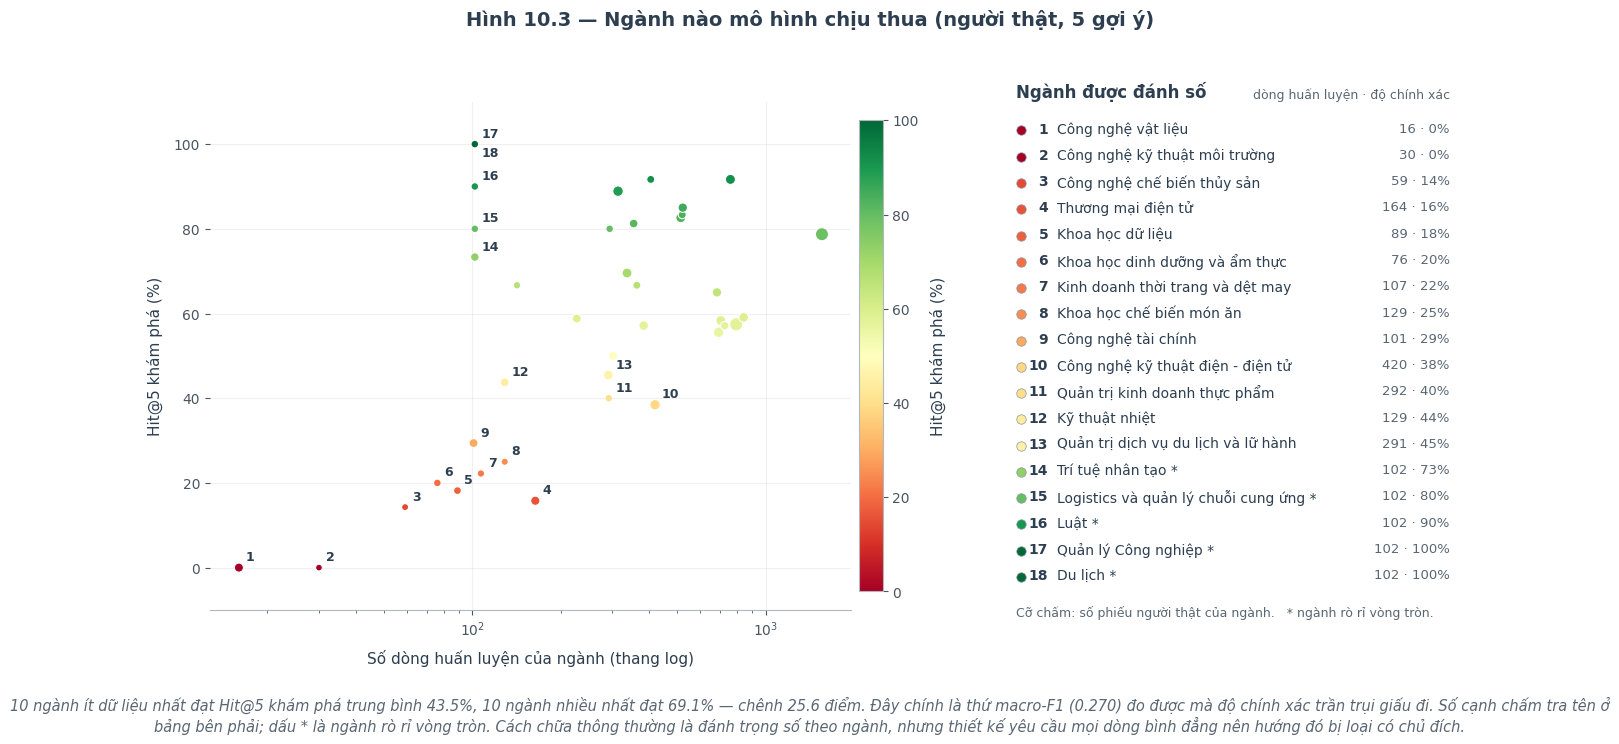

In [9]:
# ═══════════ HÌNH 10.3 — Ngành nào mô hình chịu thua ═══════════
# Đo ở điểm vận hành của tầng khám phá (K_KHAM_PHA gợi ý), trên 676 phiếu người thật.
COT_NG = f"top{K_KHAM_PHA}_kham_pha"
o = np.argsort(-S_kp_k, 1)[:, :K_KHAM_PHA]
dung = np.array([yks[i] in D["nganh"][o[i]] for i in range(len(yks))])
co_hoc = pd.Series(yh).value_counts()
ra = []
for ma in D["nganh"]:
    s = yks == ma
    if s.sum():
        ra.append({"ma": int(ma), "ten": D["ma_to_ten"][ma],
                   "nhom": int(D["nhom"][ma]),
                   "vong_tron": int(ma in NPK["nganh_vong_tron"]),
                   "n_hoc": int(co_hoc.get(ma, 0)), "n_test": int(s.sum()),
                   COT_NG: float(dung[s].mean())})
rd = pd.DataFrame(ra).sort_values("n_hoc")
rd.to_csv(OUT / "theo_nganh.csv", index=False)

fig, ax, al = hinh_theo_nganh(rd, COT_NG, f"Hit@{K_KHAM_PHA} khám phá (%)",
                              "số phiếu người thật của ngành", sao="vong_tron",
                              ghi_chu_sao="ngành rò rỉ vòng tròn")
fig.suptitle(f"Hình 10.3 — Ngành nào mô hình chịu thua (người thật, {K_KHAM_PHA} gợi ý)",
             fontsize=14, fontweight="bold", y=1.02)
nho = rd.head(10)[COT_NG].mean() * 100
lon = rd.tail(10)[COT_NG].mean() * 100
luu(fig, OUT, "hinh_10_3_theo_nganh.png",
    f"10 ngành ít dữ liệu nhất đạt Hit@{K_KHAM_PHA} khám phá trung bình {nho:.1f}%, 10 "
    f"ngành nhiều nhất đạt {lon:.1f}% — chênh {lon-nho:.1f} điểm. Đây chính là thứ "
    f"macro-F1 ({cs['f1_macro']:.3f}) đo được mà độ chính xác trần trụi giấu đi. Số cạnh "
    f"chấm tra tên ở bảng bên phải; dấu * là ngành rò rỉ vòng tròn. Cách chữa thông "
    f"thường là đánh trọng số theo ngành, nhưng thiết kế yêu cầu mọi dòng bình đẳng nên "
    f"hướng đó bị loại có chủ đích.")
plt.show()

## 3. Lưu mô hình và số liệu

In [10]:
mh.m.save_model(str(OUT / "model_nganh.json"))
if getattr(mh, "m_nhom", None):
    for g, (m_, _) in mh.m_nhom.items():
        m_.save_model(str(OUT / f"model_nhom{g}.json"))
    print(f"Đã lưu 1 mô hình chung + {len(mh.m_nhom)} mô hình nhóm")
else:
    print("Đã lưu 1 mô hình chung (tầng tư vấn dùng chính nó, che bớt ngành)")

(OUT / "lop_va_dac_trung.json").write_text(json.dumps({
    "cot_dac_trung": COT,
    "rieng_nhom": RIENG_NHOM,
    "nganh": [int(m) for m in D["nganh"]],
    "ma_to_ten": {str(k): v for k, v in D["ma_to_ten"].items()},
    "nganh_to_nhom": {str(k): int(v) for k, v in D["nhom"].items()},
    "ten_nhom": {str(k): v for k, v in D["ten_nhom"].items()},
}, ensure_ascii=False, indent=2), encoding="utf-8")

lam_tron = lambda d: {k: (None if (isinstance(v, float) and np.isnan(v)) else
                          (round(v, 4) if isinstance(v, float) else v))
                      for k, v in d.items()}

metrics = {
    "huong": 2,
    "n_hoc": int(len(hoc)), "n_test": int(len(test)),
    "n_khaosat_niemphong": int(len(ksn)),
    "n_khaosat_34_nganh": int(m_sach.sum()),
    "thiet_ke": "HƯỚNG 2 — 676 phiếu khảo sát niêm phong từ Giai đoạn 6, mô hình "
                "phân loại chưa từng thấy. Bộ sinh copula ở Giai đoạn 3 thì có.",
    "hp": STH["hp"], "rieng_nhom": RIENG_NHOM,
    "rang_buoc_gd9": STH["rang_buoc"],
    "test_noi_bo": {
        "tu_van": {f"top{k}": round(top_k(S_tv, yte, D["nganh"])[k], 4) for k in TOP_K},
        "kham_pha": {f"top{k}": round(top_k(S_kp, yte, D["nganh"])[k], 4) for k in TOP_K}},
    "khaosat_niemphong": {
        "tu_van": {f"top{k}": round(top_k(S_tv_k, yks, D["nganh"])[k], 4) for k in TOP_K},
        "kham_pha": {f"top{k}": round(top_k(S_kp_k, yks, D["nganh"])[k], 4) for k in TOP_K}},
    "khaosat_34_nganh": {
        "tu_van": {f"top{k}": round(top_k(S_tv_k[m_sach], yks[m_sach], D["nganh"])[k], 4)
                   for k in TOP_K},
        "kham_pha": {f"top{k}": round(top_k(S_kp_k[m_sach], yks[m_sach], D["nganh"])[k], 4)
                     for k in TOP_K}},
    "lac_quan_test_vs_nguoi_that": {
        f"tu_van_top{K_TU_VAN}": round(float(tv_te - tv_ks), 4),
        "kham_pha_top3": round(float(kp_te - kp_ks), 4)},
    "phan_do_5_nganh_vong_tron": {
        f"tu_van_top{K_TU_VAN}": round(float(tv_ks - tv_s), 4),
        "kham_pha_top3": round(float(kp_ks - kp_s), 4)},
    "train_val": {
        "tu_van": {f"top{k}": round(top_k(S_tv_h, yh, D["nganh"])[k], 4) for k in TOP_K},
        "kham_pha": {f"top{k}": round(top_k(S_kp_h, yh, D["nganh"])[k], 4) for k in TOP_K}},
    "diem_van_hanh": {"tu_van": K_TU_VAN, "kham_pha": K_KHAM_PHA},
    "gap_train_test": {"tu_van": round(float(tv_h - tv_te), 4),
                       "kham_pha": round(float(gap_kp), 4),
                       "k": {"tu_van": K_TU_VAN, "kham_pha": 3}},
    "gap_train_nguoi_that": {"tu_van": round(float(tv_h - tv_ks), 4),
                             "kham_pha": round(float(gap_kp_ks), 4)},
    "doan_bua": {
        "tu_van_trong_nhom": {f"top{k}": round(bua_tv_k[k], 4) for k in TOP_K},
        "tu_van_nganh_dong_nhat": {f"top{k}": round(bua_pb_k[k], 4) for k in TOP_K},
        "kham_pha": {f"top{k}": round(bua_kp[k], 4) for k in TOP_K}},
    "ky_nang_nguoi_that": {
        f"tu_van_top{K_TU_VAN}": round(ky_nang(tv_ks, bua_tv_k[K_TU_VAN]), 4),
        "kham_pha_top3": round(ky_nang(kp_ks, bua_kp[3]), 4),
        f"kham_pha_top{K_KHAM_PHA}": round(ky_nang(
            top_k(S_kp_k, yks, D["nganh"])[K_KHAM_PHA], bua_kp[K_KHAM_PHA]), 4)},
    "chi_so_xep_hang": {t_: {**lam_tron(d_), "mrr_doan_bua": round(mb, 4)}
                        for t_, d_, mb in xh},
    "chi_so_lop": {n_: lam_tron(d_) for n_, d_, _ in hang},
    "sai_so_95_nguoi_that": {f"tu_van_top{K_TU_VAN}": round(float(ci(tv_ks, len(ksn))), 1),
                             "kham_pha_top3": round(float(ci(kp_ks, len(ksn))), 1)},
    "han_che": [
        "Mô hình phân loại chưa từng thấy phiếu nào trong 676 phiếu niêm phong, "
        "nhưng bộ sinh copula ở Giai đoạn 3 CÓ học từ chúng. Không tránh được: "
        "ngành ít phiếu nhất chỉ có 6 phiếu, chia đôi thì không ước lượng nổi ma "
        "trận hiệp phương sai. Đừng viết 'hoàn toàn độc lập'.",
        f"5 ngành (Luật, Trí tuệ nhân tạo, Quản lý Công nghiệp, Logistics, Du lịch) "
        f"không có hồ sơ trúng tuyển nào; dòng huấn luyện của chúng sinh từ chính "
        f"{int((~m_sach).sum())} phiếu bị niêm phong — rò rỉ vòng tròn. Cột "
        f"'khaosat_34_nganh' loại bỏ chúng.",
        f"Mất cân bằng theo ngành: 10 ngành ít dữ liệu nhất đạt Hit@{K_KHAM_PHA} khám phá "
        f"{nho:.1f}%, 10 ngành nhiều nhất {lon:.1f}%. macro-F1 {cs['f1_macro']:.3f} "
        f"so với weighted-F1 {cs['f1_weighted']:.3f} đo cùng hiện tượng đó.",
        "Phần Likert của 15.696 hồ sơ TTTH do copula sinh, không phải các em tự điền; "
        "điểm, tổ hợp và ngành trúng tuyển là thật.",
    ],
}
(OUT / "metrics.json").write_text(
    json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 10 — CHỐT MÔ HÌNH (HƯỚNG 2)", [
    f"Huấn luyện        {len(hoc):,} dòng · 100% từ hồ sơ trúng tuyển",
    f"Test nội bộ       {len(test):,} dòng · băm khớp",
    f"NGƯỜI THẬT        {len(ksn):,} phiếu · niêm phong từ GĐ 6, băm khớp  ⭐",
    "",
    f"BA CÁCH ĐO (tư vấn Top-{K_TU_VAN} · khám phá Top-3):",
    f"   {'':20}{'tư vấn':>10}{'khám phá':>11}",
    f"   {'TRAIN+VAL':<20}{tv_h:>10.1%}{kp_h:>11.1%}",
    f"   {'TEST nội bộ':<20}{tv_te:>10.1%}{kp_te:>11.1%}",
    f"   {'NGƯỜI THẬT ⭐':<20}{tv_ks:>10.1%}{kp_ks:>11.1%}",
    f"   {'NGƯỜI THẬT 34 ngành':<20}{tv_s:>10.1%}{kp_s:>11.1%}",
    f"   {'đoán bừa':<20}{bua_tv_k[K_TU_VAN]:>10.1%}{bua_kp[3]:>11.1%}",
    "",
    f"Lạc quan do d.liệu sinh  tư vấn {(tv_te-tv_ks)*100:+.1f}đ"
    f" · khám phá {(kp_te-kp_ks)*100:+.1f}đ",
    f"Phần do 5 ngành v.tròn   tư vấn {(tv_ks-tv_s)*100:+.1f}đ"
    f" · khám phá {(kp_ks-kp_s)*100:+.1f}đ",
    "",
    f"⭐ ĐIỂM VẬN HÀNH, đo trên NGƯỜI THẬT ({K_TU_VAN} gợi ý / {K_KHAM_PHA} gợi ý):",
    f"   {'':12}{'tư vấn @' + str(K_TU_VAN):>12}{'kh.phá @' + str(K_KHAM_PHA):>12}",
    f"   {'Hit@k':<12}{dtv['hit_k']:>12.1%}{dkp['hit_k']:>12.1%}",
    f"   {'macro Hit@k':<12}{dtv['macro_hit_k']:>12.1%}{dkp['macro_hit_k']:>12.1%}",
    f"   {'MRR':<12}{dtv['mrr']:>12.3f}{dkp['mrr']:>12.3f}",
    f"   {'NDCG@k':<12}{dtv['ndcg_k']:>12.3f}{dkp['ndcg_k']:>12.3f}",
    f"   {'hạng t.vị':<12}{dtv['hang_trung_vi']:>12.0f}{dkp['hang_trung_vi']:>12.0f}",
    "",
    f"macro-F1 (Top-1)  tư vấn {cs_tv['f1_macro']:.3f}"
    f" · khám phá {cs['f1_macro']:.3f}",
    f"Kỹ năng           tư vấn Top-{K_TU_VAN} {ky_nang(tv_ks, bua_tv_k[K_TU_VAN]):.1%}"
    f" · khám phá Top-3 {ky_nang(kp_ks, bua_kp[3]):.1%}",
    "",
    "⚠️  Hạn chế đã ghi trong metrics.json — đưa vào báo cáo",
])
print(f"\n✅ metrics.json · model_nganh.json · bang_ket_qua.csv · chi_so_lop.csv"
      f" · theo_nganh.csv · 3 hình  →  {OUT}")

Đã lưu 1 mô hình chung + 9 mô hình nhóm


╔════════════════════════════════════════════════════════════════════════════╗
║                   GIAI ĐOẠN 10 — CHỐT MÔ HÌNH (HƯỚNG 2)                    ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Huấn luyện        13,851 dòng · 100% từ hồ sơ trúng tuyển                  ║
║ Test nội bộ       2,445 dòng · băm khớp                                    ║
║ NGƯỜI THẬT        676 phiếu · niêm phong từ GĐ 6, băm khớp  ⭐              ║
║                                                                            ║
║ BA CÁCH ĐO (tư vấn Top-2 · khám phá Top-3):                                ║
║                            tư vấn   khám phá                               ║
║    TRAIN+VAL                95.1%      77.8%                               ║
║    TEST nội bộ              91.3%      71.4%                               ║
║    NGƯỜI THẬT ⭐             78.6%      51.3%                               ║
║    NGƯỜI THẬT 34 ngành      77.2%      48.9%      